In [2]:
pwd

'c:\\Users\\smm931389\\Desktop\\RAG_patterns\\Experiment'

In [3]:
from langchain_openai import AzureOpenAIEmbeddings

import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv(override=True)

def get_azure_embedding_model():
    return AzureOpenAIEmbeddings(
        azure_deployment=os.getenv("AZURE_OPENAI_EMBEDDING_DEPLOYMENT"),
        azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
        api_key=os.getenv("AZURE_OPENAI_API_KEY"),
        api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
    )

In [4]:
from langchain_community.vectorstores import FAISS

def get_vectorstore():
    """Load the FAISS vector store."""
   
    # Load environment variables
    load_dotenv(override=True)

    # Load embeddings
    embeddings = get_azure_embedding_model()

    # === Load FAISS index ===
    faiss_path = r"C:\Users\smm931389\Desktop\RAG_patterns\faiss_index_financial"
    vectorstore = FAISS.load_local(
        faiss_path,
        embeddings=embeddings,  # not required for searching
        allow_dangerous_deserialization=True
    )
    
    return vectorstore

In [5]:
from langchain_openai import ChatOpenAI
from langchain.schema import HumanMessage

def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",  # or another Groq model you have access to
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.7,
        max_tokens=1024,
    )

In [6]:
from dotenv import load_dotenv

load_dotenv(override=True)
embeddings = get_azure_embedding_model()
vectorstore = get_vectorstore()

search_kwargs = {"k": 3}
roles = ["analyst"]  # Example roles to filter by
if roles:
    # FAISS supports $in filter for metadata
    search_kwargs["filter"] = {"role": {"$in": roles}}

retriever = vectorstore.as_retriever(search_kwargs=search_kwargs)


In [7]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

llm = get_groq_llm()

template = """Answer the question based on the following context and the Chathistory. Especially take the latest question into consideration:

Chathistory: {history}

Context: {context}

Question: {question}
"""
prompt = ChatPromptTemplate.from_template(template)
rag_chain = prompt | llm

In [8]:
off_topic_llm = get_groq_llm()

template = """
When a user asks an off-topic question (not related to finance):

Provide a short, polite answer to acknowledge their query.

Immediately and firmly remind the user that you are built specifically for finance-related queries.

Encourage them to return to finance-related questions, since that’s where you can provide real value.

If relevant, use the chat history to make your reminder more natural and connected to past discussions.

Always maintain a friendly but professional tone.

chat_history: {history}

Question: {question}
"""
prompt = ChatPromptTemplate.from_template(template)
off_topic_rag_chain = prompt | off_topic_llm

In [9]:
from langchain_community.utilities import SerpAPIWrapper

In [ ]:
from typing import TypedDict, List
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain.schema import Document
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, END


class AgentState(TypedDict):
    messages: List[BaseMessage]
    documents: List[Document]
    on_topic: str
    rephrased_question: str
    proceed_to_generate: bool
    rephrase_count: int
    question: HumanMessage


class GradeQuestion(BaseModel):
    score: str = Field(
        description="Question is about the specified topics? If yes -> 'Yes' if not -> 'No'"
    )


def question_rewriter(state: AgentState):
    print(f"Entering question_rewriter with following state: {state}")

    # Reset state variables except for 'question' and 'messages'
    state["documents"] = []
    state["on_topic"] = ""
    state["rephrased_question"] = ""
    state["proceed_to_generate"] = False
    state["rephrase_count"] = 0

    if "messages" not in state or state["messages"] is None:
        state["messages"] = []

    if state["question"] not in state["messages"]:
        state["messages"].append(state["question"])

    if len(state["messages"]) > 1:
        conversation = state["messages"][:-1]
        current_question = state["question"].content
        messages = [
            SystemMessage(
                content="You are a helpful financial assistant that rephrases the user's question to be a standalone question optimized for retrieval."
            )
        ]
        messages.extend(conversation)
        messages.append(HumanMessage(content=current_question))
        rephrase_prompt = ChatPromptTemplate.from_messages(messages)
        llm = get_groq_llm()
        prompt = rephrase_prompt.format()
        response = llm.invoke(prompt)
        better_question = response.content.strip()
        print(f"question_rewriter: Rephrased question: {better_question}")
        state["rephrased_question"] = better_question
    else:
        state["rephrased_question"] = state["question"].content
    return state

def question_classifier(state: AgentState):
    print("Entering question_classifier")
    system_message = SystemMessage(
        content=""" You are a classifier that determines whether a user's question is about one of the following Financial topics 
    
    1. About Deutsche Bank and it's financial services/reports
    2. About jp morgan chase & co and it's financial services/reports
    3. About Hindustan Unilever and it's financial services/reports
    4. Any question related to stock market, investment, banking, finance, financial analysis, financial reports, financial services, economic trends, market analysis, investment strategies, financial planning, asset management, wealth management, corporate finance, personal finance, financial regulations, financial technology (fintech), or financial markets.
    
    If the question IS about any of these topics, respond with 'Yes'. Otherwise, respond with 'No'.

    """
    )

    human_message = HumanMessage(
        content=f"User question: {state['rephrased_question']}"
    )
    grade_prompt = ChatPromptTemplate.from_messages([system_message, human_message])
    llm = get_groq_llm()
    structured_llm = llm.with_structured_output(GradeQuestion)
    grader_llm = grade_prompt | structured_llm
    result = grader_llm.invoke({})
    state["on_topic"] = result.score.strip()
    print(f"question_classifier: on_topic = {state['on_topic']}")
    return state

def on_topic_router(state: AgentState):
    print("Entering on_topic_router")
    on_topic = state.get("on_topic", "").strip().lower()
    if on_topic == "yes":
        print("Routing to retrieve")
        return "retrieve"
    else:
        print("Routing to off_topic_response")
        return "off_topic_response"


def retrieve(state: AgentState):
    print("Entering retrieve")
    documents = retriever.invoke(state["rephrased_question"])
    print(f"retrieve: Retrieved {len(documents)} documents")
    state["documents"] = documents
    return state


class GradeDocument(BaseModel):
    score: str = Field(
        description="Document is relevant to the question? If yes -> 'Yes' if not -> 'No'"
    )

def retrieval_grader(state: AgentState):
    print("Entering retrieval_grader")
    system_message = SystemMessage(
        content="""You are a grader assessing the relevance of a retrieved document to a user question.
Only answer with 'Yes' or 'No'.

If the document contains information relevant to the user's question, respond with 'Yes'.
Otherwise, respond with 'No'."""
    )

    llm = get_groq_llm()
    structured_llm = llm.with_structured_output(GradeDocument)

    relevant_docs = []
    for doc in state["documents"]:
        human_message = HumanMessage(
            content=f"User question: {state['rephrased_question']}\n\nRetrieved document:\n{doc.page_content}"
        )
        grade_prompt = ChatPromptTemplate.from_messages([system_message, human_message])
        grader_llm = grade_prompt | structured_llm
        result = grader_llm.invoke({})
        print(
            f"Grading document: {doc.page_content[:30]}... Result: {result.score.strip()}"
        )
        if result.score.strip().lower() == "yes":
            relevant_docs.append(doc)
    state["documents"] = relevant_docs
    state["proceed_to_generate"] = len(relevant_docs) > 0
    print(f"retrieval_grader: proceed_to_generate = {state['proceed_to_generate']}")
    return state

def proceed_router(state: AgentState):
    print("Entering proceed_router")
    rephrase_count = state.get("rephrase_count", 0)
    if state.get("proceed_to_generate", False):
        print("Routing to generate_answer")
        return "generate_answer"
    elif rephrase_count >= 2:
        print("Maximum rephrase attempts reached. Cannot find relevant documents.")
        return "search_internet"
    else:
        print("Routing to refine_question")
        return "refine_question"
    
def refine_question(state: AgentState):
    print("Entering refine_question")
    rephrase_count = state.get("rephrase_count", 0)
    if rephrase_count >= 2:
        print("Maximum rephrase attempts reached")
        return state
    question_to_refine = state["rephrased_question"]
    system_message = SystemMessage(
        content="""You are a helpful financial assistant that slightly refines the user's question to improve retrieval results.
Provide a slightly adjusted version of the question."""
    )
    human_message = HumanMessage(
        content=f"Original question: {question_to_refine}\n\nProvide a slightly refined question."
    )
    refine_prompt = ChatPromptTemplate.from_messages([system_message, human_message])
    llm = get_groq_llm()
    prompt = refine_prompt.format()
    response = llm.invoke(prompt)
    refined_question = response.content.strip()
    print(f"refine_question: Refined question: {refined_question}")
    state["rephrased_question"] = refined_question
    state["rephrase_count"] = rephrase_count + 1
    return state

def generate_answer(state: AgentState):
    print("Entering generate_answer")
    if "messages" not in state or state["messages"] is None:
        raise ValueError("State must include 'messages' before generating an answer.")

    history = state["messages"]
    documents = state["documents"]
    rephrased_question = state["rephrased_question"]

    response = rag_chain.invoke(
        {"history": history, "context": documents, "question": rephrased_question}
    )

    generation = response.content.strip()

    state["messages"].append(AIMessage(content=generation))
    print(f"generate_answer: Generated response: {generation}")
    return state

# def cannot_answer(state: AgentState):
#     print("Entering cannot_answer")
#     if "messages" not in state or state["messages"] is None:
#         state["messages"] = []
#     state["messages"].append(
#         AIMessage(
#             content="I'm sorry, but I cannot find the information you're looking for."
#         )
#     )
#     return state

def search_internet(state: AgentState):
    print("Entering search_internet")
    search = SerpAPIWrapper()
    if "messages" not in state or state["messages"] is None:
        raise ValueError("State must include 'messages' before generating an answer.")
    rephrased_question = state["rephrased_question"]
    
    search_results = search.run(rephrased_question)
    state["messages"].append(
        AIMessage(
            content=search_results
        )
    )
    print(f"search_internet: Search results: {search_results}")
    return state


def off_topic_response(state: AgentState):
    print("Entering off_topic_response")
    if "messages" not in state or state["messages"] is None:
        state["messages"] = []
    history = state["messages"]
    response= off_topic_rag_chain.invoke(
        {"history": history, "question": state['question']}
    )
    final_answer = response.content.strip()
    state["messages"].append(AIMessage(content=final_answer))
    print(f"off_topic_response: Final answer: {final_answer}")
    return state

In [11]:
### In memory checkpointing (disabled for now)

# from langgraph.checkpoint.memory import MemorySaver

# checkpointer = MemorySaver()

In [12]:
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3


In [13]:
sqlite_conn = sqlite3.connect("financebot.sqlite", check_same_thread=False)

checkpointer = SqliteSaver(sqlite_conn)


In [14]:
# Workflow
workflow = StateGraph(AgentState)
workflow.add_node("question_rewriter", question_rewriter)
workflow.add_node("question_classifier", question_classifier)
workflow.add_node("off_topic_response", off_topic_response)
workflow.add_node("retrieve", retrieve)
workflow.add_node("retrieval_grader", retrieval_grader)
workflow.add_node("generate_answer", generate_answer)
workflow.add_node("refine_question", refine_question)
#workflow.add_node("cannot_answer", cannot_answer)
workflow.add_node("search_internet", search_internet)

workflow.add_edge("question_rewriter", "question_classifier")
workflow.add_conditional_edges(
    "question_classifier",
    on_topic_router,
    {
        "retrieve": "retrieve",
        "off_topic_response": "off_topic_response",
    },
)
workflow.add_edge("retrieve", "retrieval_grader")
workflow.add_conditional_edges(
    "retrieval_grader",
    proceed_router,
    {
        "generate_answer": "generate_answer",
        "refine_question": "refine_question",
        "search_internet": "search_internet",
    },
)
workflow.add_edge("refine_question", "retrieve")
workflow.add_edge("generate_answer", END)
#workflow.add_edge("cannot_answer", "search_internet")
workflow.add_edge("search_internet", END)
workflow.add_edge("off_topic_response", END)
workflow.set_entry_point("question_rewriter")
graph = workflow.compile(checkpointer=checkpointer)

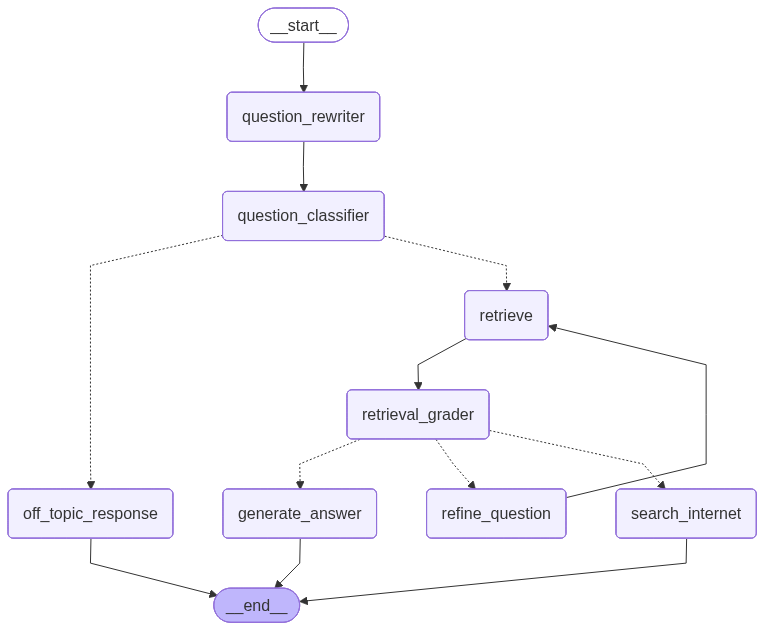

In [15]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

Off Topic: 

In [16]:
input_data = {"question": HumanMessage(content="What does the company Apple do?")}
graph.invoke(input=input_data, config={"configurable": {"thread_id": 1}})


Entering question_rewriter with following state: {'question': HumanMessage(content='What does the company Apple do?', additional_kwargs={}, response_metadata={})}
Entering question_classifier
question_classifier: on_topic = No
Entering on_topic_router
Routing to off_topic_response
Entering off_topic_response
off_topic_response: Final answer: I’m glad you’re curious about Apple! Apple Inc. is a global technology company that designs, manufactures, and markets consumer electronics (like the iPhone, iPad, Mac, and Apple Watch), software, and related services.

Just a quick reminder: I’m specifically tuned to help with finance‑related questions—such as market analysis, investment strategies, and financial planning. If you have any finance‑focused inquiries, feel free to ask, and I’ll be happy to dive in!


{'messages': [HumanMessage(content='What does the company Apple do?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='I’m glad you’re curious about Apple! Apple Inc. is a global technology company that designs, manufactures, and markets consumer electronics (like the iPhone, iPad, Mac, and Apple Watch), software, and related services.\n\nJust a quick reminder: I’m specifically tuned to help with finance‑related questions—such as market analysis, investment strategies, and financial planning. If you have any finance‑focused inquiries, feel free to ask, and I’ll be happy to dive in!', additional_kwargs={}, response_metadata={})],
 'documents': [],
 'on_topic': 'No',
 'rephrased_question': 'What does the company Apple do?',
 'proceed_to_generate': False,
 'rephrase_count': 0,
 'question': HumanMessage(content='What does the company Apple do?', additional_kwargs={}, response_metadata={})}

off topic only

In [17]:
input_data = {
    "question": HumanMessage(
        content="hi there My name is Sachin, how are you doing today?"
    )
}
graph.invoke(input=input_data, config={"configurable": {"thread_id": 1}})

Entering question_rewriter with following state: {'messages': [HumanMessage(content='What does the company Apple do?', additional_kwargs={}, response_metadata={}), AIMessage(content='I’m glad you’re curious about Apple! Apple Inc. is a global technology company that designs, manufactures, and markets consumer electronics (like the iPhone, iPad, Mac, and Apple Watch), software, and related services.\n\nJust a quick reminder: I’m specifically tuned to help with finance‑related questions—such as market analysis, investment strategies, and financial planning. If you have any finance‑focused inquiries, feel free to ask, and I’ll be happy to dive in!', additional_kwargs={}, response_metadata={})], 'documents': [], 'on_topic': 'No', 'rephrased_question': 'What does the company Apple do?', 'proceed_to_generate': False, 'rephrase_count': 0, 'question': HumanMessage(content='hi there My name is Sachin, how are you doing today?', additional_kwargs={}, response_metadata={})}
question_rewriter: Rep

{'messages': [HumanMessage(content='What does the company Apple do?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='I’m glad you’re curious about Apple! Apple Inc. is a global technology company that designs, manufactures, and markets consumer electronics (like the iPhone, iPad, Mac, and Apple Watch), software, and related services.\n\nJust a quick reminder: I’m specifically tuned to help with finance‑related questions—such as market analysis, investment strategies, and financial planning. If you have any finance‑focused inquiries, feel free to ask, and I’ll be happy to dive in!', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='hi there My name is Sachin, how are you doing today?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Hi Sachin! I’m doing well—thanks for asking. I’m here to help with finance‑related questions, such as market analysis, investment strategies, or financial planning. If you have anything along those line

In [18]:
input_data = {
    "question": HumanMessage(
        content="do you remeber my name?"
    )
}
graph.invoke(input=input_data, config={"configurable": {"thread_id": 1}})

Entering question_rewriter with following state: {'messages': [HumanMessage(content='What does the company Apple do?', additional_kwargs={}, response_metadata={}), AIMessage(content='I’m glad you’re curious about Apple! Apple Inc. is a global technology company that designs, manufactures, and markets consumer electronics (like the iPhone, iPad, Mac, and Apple Watch), software, and related services.\n\nJust a quick reminder: I’m specifically tuned to help with finance‑related questions—such as market analysis, investment strategies, and financial planning. If you have any finance‑focused inquiries, feel free to ask, and I’ll be happy to dive in!', additional_kwargs={}, response_metadata={}), HumanMessage(content='hi there My name is Sachin, how are you doing today?', additional_kwargs={}, response_metadata={}), AIMessage(content='Hi Sachin! I’m doing well—thanks for asking. I’m here to help with finance‑related questions, such as market analysis, investment strategies, or financial plan

{'messages': [HumanMessage(content='What does the company Apple do?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='I’m glad you’re curious about Apple! Apple Inc. is a global technology company that designs, manufactures, and markets consumer electronics (like the iPhone, iPad, Mac, and Apple Watch), software, and related services.\n\nJust a quick reminder: I’m specifically tuned to help with finance‑related questions—such as market analysis, investment strategies, and financial planning. If you have any finance‑focused inquiries, feel free to ask, and I’ll be happy to dive in!', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='hi there My name is Sachin, how are you doing today?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Hi Sachin! I’m doing well—thanks for asking. I’m here to help with finance‑related questions, such as market analysis, investment strategies, or financial planning. If you have anything along those line

In [19]:
input_data = {
    "question": HumanMessage(
        content="okay my name is Sachin, just remember my name whenever ask tell me"
    )
}
graph.invoke(input=input_data, config={"configurable": {"thread_id": 1}})

Entering question_rewriter with following state: {'messages': [HumanMessage(content='What does the company Apple do?', additional_kwargs={}, response_metadata={}), AIMessage(content='I’m glad you’re curious about Apple! Apple Inc. is a global technology company that designs, manufactures, and markets consumer electronics (like the iPhone, iPad, Mac, and Apple Watch), software, and related services.\n\nJust a quick reminder: I’m specifically tuned to help with finance‑related questions—such as market analysis, investment strategies, and financial planning. If you have any finance‑focused inquiries, feel free to ask, and I’ll be happy to dive in!', additional_kwargs={}, response_metadata={}), HumanMessage(content='hi there My name is Sachin, how are you doing today?', additional_kwargs={}, response_metadata={}), AIMessage(content='Hi Sachin! I’m doing well—thanks for asking. I’m here to help with finance‑related questions, such as market analysis, investment strategies, or financial plan

{'messages': [HumanMessage(content='What does the company Apple do?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='I’m glad you’re curious about Apple! Apple Inc. is a global technology company that designs, manufactures, and markets consumer electronics (like the iPhone, iPad, Mac, and Apple Watch), software, and related services.\n\nJust a quick reminder: I’m specifically tuned to help with finance‑related questions—such as market analysis, investment strategies, and financial planning. If you have any finance‑focused inquiries, feel free to ask, and I’ll be happy to dive in!', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='hi there My name is Sachin, how are you doing today?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Hi Sachin! I’m doing well—thanks for asking. I’m here to help with finance‑related questions, such as market analysis, investment strategies, or financial planning. If you have anything along those line

In [20]:
print("2"--)

SyntaxError: invalid syntax (3485455711.py, line 1)

In [21]:
input_data = {
    "question": HumanMessage(
        content="okay now tell me my name and how apple compnay did in last 5 years in 2-3 lines"
    )
}
graph.invoke(input=input_data, config={"configurable": {"thread_id": 1}})

Entering question_rewriter with following state: {'messages': [HumanMessage(content='What does the company Apple do?', additional_kwargs={}, response_metadata={}), AIMessage(content='I’m glad you’re curious about Apple! Apple Inc. is a global technology company that designs, manufactures, and markets consumer electronics (like the iPhone, iPad, Mac, and Apple Watch), software, and related services.\n\nJust a quick reminder: I’m specifically tuned to help with finance‑related questions—such as market analysis, investment strategies, and financial planning. If you have any finance‑focused inquiries, feel free to ask, and I’ll be happy to dive in!', additional_kwargs={}, response_metadata={}), HumanMessage(content='hi there My name is Sachin, how are you doing today?', additional_kwargs={}, response_metadata={}), AIMessage(content='Hi Sachin! I’m doing well—thanks for asking. I’m here to help with finance‑related questions, such as market analysis, investment strategies, or financial plan

{'messages': [HumanMessage(content='What does the company Apple do?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='I’m glad you’re curious about Apple! Apple Inc. is a global technology company that designs, manufactures, and markets consumer electronics (like the iPhone, iPad, Mac, and Apple Watch), software, and related services.\n\nJust a quick reminder: I’m specifically tuned to help with finance‑related questions—such as market analysis, investment strategies, and financial planning. If you have any finance‑focused inquiries, feel free to ask, and I’ll be happy to dive in!', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='hi there My name is Sachin, how are you doing today?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Hi Sachin! I’m doing well—thanks for asking. I’m here to help with finance‑related questions, such as market analysis, investment strategies, or financial planning. If you have anything along those line

#### Docs found type

In [ ]:
input_data = {
    "question": HumanMessage(
        content="tell me about Deutsche Bank's 2030 plan?"
    )
}
graph.invoke(input=input_data, config={"configurable": {"thread_id": 1}})

Entering question_rewriter with following state: {'messages': [HumanMessage(content='What does the company Apple do?', additional_kwargs={}, response_metadata={}), AIMessage(content="I'm sorry! I cannot answer this question! Ask me Finance related questions only.", additional_kwargs={}, response_metadata={}), HumanMessage(content='hi there how are you doing today?', additional_kwargs={}, response_metadata={}), AIMessage(content="I'm sorry! I cannot answer this question! Ask me Finance related questions only.", additional_kwargs={}, response_metadata={}), HumanMessage(content="tell me about Deutsche Bank's financial services.", additional_kwargs={}, response_metadata={}), AIMessage(content='Deutsche\u202fBank offers a broad spectrum of financial services across its three main business divisions – **Corporate Bank, Private Bank, and Investment Bank** – each tailored to different client segments and product categories.\n\n| Division | Core Services & Product Mix | Key Client Segments |\n|

{'messages': [HumanMessage(content='What does the company Apple do?', additional_kwargs={}, response_metadata={}),
  AIMessage(content="I'm sorry! I cannot answer this question! Ask me Finance related questions only.", additional_kwargs={}, response_metadata={}),
  HumanMessage(content='hi there how are you doing today?', additional_kwargs={}, response_metadata={}),
  AIMessage(content="I'm sorry! I cannot answer this question! Ask me Finance related questions only.", additional_kwargs={}, response_metadata={}),
  HumanMessage(content="tell me about Deutsche Bank's financial services.", additional_kwargs={}, response_metadata={}),
  AIMessage(content='Deutsche\u202fBank offers a broad spectrum of financial services across its three main business divisions – **Corporate Bank, Private Bank, and Investment Bank** – each tailored to different client segments and product categories.\n\n| Division | Core Services & Product Mix | Key Client Segments |\n|----------|----------------------------

### docs found type

In [ ]:
input_data = {
    "question": HumanMessage(content="Who founded Deutsche Bank?")
}
graph.invoke(input=input_data, config={"configurable": {"thread_id": 3}})

Entering question_rewriter with following state: {'question': HumanMessage(content='Who founded Deutsche Bank?', additional_kwargs={}, response_metadata={})}
Entering question_classifier
question_classifier: on_topic = Yes
Entering on_topic_router
Routing to retrieve
Entering retrieve
retrieve: Retrieved 3 documents
Entering retrieval_grader
Grading document: 42 
 
 
 Deutsche Bank   
 Ann... Result: Yes
Grading document: 409 
  
 Deutsche Bank   
 Ann... Result: No
Grading document: 10 
 
 
 Deutsche Bank   
 Ann... Result: No
retrieval_grader: proceed_to_generate = True
Entering proceed_router
Routing to generate_answer
Entering generate_answer
generate_answer: Generated response: Deutsche Bank Aktiengesellschaft was founded in **1870**【source】.


{'messages': [HumanMessage(content='Who founded Deutsche Bank?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Deutsche\u202fBank\u202fAktiengesellschaft was founded in **1870**【source】.', additional_kwargs={}, response_metadata={})],
 'documents': [Document(id='4973806e-0afe-4c77-955a-c5ddf146ccc6', metadata={'producer': 'Adobe Acrobat Pro (32-bit) 23.1.20143', 'creator': 'Adobe Acrobat Pro (32-bit) 23.1.20143', 'creationdate': '2024-04-17T18:38:09+02:00', 'keywords': 'Public', 'moddate': '2024-04-18T10:14:03+02:00', 'source': 'C:\\Users\\smm931389\\Desktop\\RAG_patterns\\financial_pdfs\\DB_Annual_2023.pdf', 'total_pages': 701, 'page': 41, 'page_label': '42', 'file_name': 'DB_Annual_2023.pdf', 'role': 'analyst'}, page_content='42 \n \n \n Deutsche Bank   \n Annual Report 2023 on Form 20-F  \n   \n  \nItem 4: Information on the company  \nHistory and development of the company \nThe legal and commercial name of the company is Deutsche Bank Aktiengesellschaft. It is 

No docs found type where internet search is required

In [ ]:
input_data = {
    "question": HumanMessage(content="explain me the concept of blockchain?")
}
graph.invoke(input=input_data, config={"configurable": {"thread_id": 3}})

Entering question_rewriter with following state: {'messages': [HumanMessage(content='what is fund tarnsfer pricing?', additional_kwargs={}, response_metadata={}), AIMessage(content='**Funds Transfer Pricing (FTP)**\n\nFunds Transfer Pricing is an internal pricing framework that a bank uses to **allocate the costs and benefits of liquidity (funding) across its business units**.  \n\nKey points from the Deutsche\u202fBank Annual Report (2023):\n\n| What it does | How it works |\n|--------------|--------------|\n| **Incentivises liquidity‑steering** | All corporate divisions and entities that hold balance‑sheet items are charged or credited with a rate that reflects the true economic cost of liquidity. |\n| **Prices assets, liabilities and contingent exposures** | • Assets are priced according to their underlying liquidity risk.<br>• Liabilities are priced according to their liquidity value.<br>• Contingent exposures (e.g., potential future funding needs) are priced based on the cost of h

{'messages': [HumanMessage(content='what is fund tarnsfer pricing?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='**Funds Transfer Pricing (FTP)**\n\nFunds Transfer Pricing is an internal pricing framework that a bank uses to **allocate the costs and benefits of liquidity (funding) across its business units**.  \n\nKey points from the Deutsche\u202fBank Annual Report (2023):\n\n| What it does | How it works |\n|--------------|--------------|\n| **Incentivises liquidity‑steering** | All corporate divisions and entities that hold balance‑sheet items are charged or credited with a rate that reflects the true economic cost of liquidity. |\n| **Prices assets, liabilities and contingent exposures** | • Assets are priced according to their underlying liquidity risk.<br>• Liabilities are priced according to their liquidity value.<br>• Contingent exposures (e.g., potential future funding needs) are priced based on the cost of holding high‑quality liquid assets. |\n| **Alloc

rag with history type

In [ ]:
input_data = {"question": HumanMessage(content="what is fund tarnsfer pricing?")}
graph.invoke(input=input_data, config={"configurable": {"thread_id": 3}})

Entering question_rewriter with following state: {'question': HumanMessage(content='what is fund tarnsfer pricing?', additional_kwargs={}, response_metadata={})}
Entering question_classifier
question_classifier: on_topic = Yes
Entering on_topic_router
Routing to retrieve
Entering retrieve
retrieve: Retrieved 3 documents
Entering retrieval_grader
Grading document: 23 
  
   where,              ... Result: No
Grading document: 111 
 
 
 Deutsche Bank   
 An... Result: Yes
Grading document: 200 
 
 
 Deutsche Bank   
 An... Result: No
retrieval_grader: proceed_to_generate = True
Entering proceed_router
Routing to generate_answer
Entering generate_answer
generate_answer: Generated response: **Funds Transfer Pricing (FTP)**

Funds Transfer Pricing is an internal pricing framework that a bank uses to **allocate the costs and benefits of liquidity (funding) across its business units**.  

Key points from the Deutsche Bank Annual Report (2023):

| What it does | How it works |
|--------------|

{'messages': [HumanMessage(content='what is fund tarnsfer pricing?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='**Funds Transfer Pricing (FTP)**\n\nFunds Transfer Pricing is an internal pricing framework that a bank uses to **allocate the costs and benefits of liquidity (funding) across its business units**.  \n\nKey points from the Deutsche\u202fBank Annual Report (2023):\n\n| What it does | How it works |\n|--------------|--------------|\n| **Incentivises liquidity‑steering** | All corporate divisions and entities that hold balance‑sheet items are charged or credited with a rate that reflects the true economic cost of liquidity. |\n| **Prices assets, liabilities and contingent exposures** | • Assets are priced according to their underlying liquidity risk.<br>• Liabilities are priced according to their liquidity value.<br>• Contingent exposures (e.g., potential future funding needs) are priced based on the cost of holding high‑quality liquid assets. |\n| **Alloc

In [ ]:
input_data = {"question": HumanMessage(content="what is the mechanism behind it?")}
graph.invoke(input=input_data, config={"configurable": {"thread_id": 3}})

Entering question_rewriter with following state: {'messages': [HumanMessage(content='Who founded Deutsche Bank?', additional_kwargs={}, response_metadata={}), AIMessage(content='Deutsche\u202fBank\u202fAktiengesellschaft was founded in **1870**【source】.', additional_kwargs={}, response_metadata={}), HumanMessage(content='explain me the concept of blockchain?', additional_kwargs={}, response_metadata={}), AIMessage(content="I'm sorry, but I cannot find the information you're looking for.", additional_kwargs={}, response_metadata={}), HumanMessage(content='what is fund tarnsfer pricing?', additional_kwargs={}, response_metadata={}), AIMessage(content='**Fund Transfer Pricing (FTP)** is Deutsche\u202fBank’s internal pricing system that allocates the bank’s funding and liquidity‑risk costs (and benefits) to its individual business units.  \nKey points from the 2023 Annual Report:\n\n| Aspect | What FTP does |\n|--------|---------------|\n| **Purpose** | Incentivises each division to manage

{'messages': [HumanMessage(content='Who founded Deutsche Bank?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Deutsche\u202fBank\u202fAktiengesellschaft was founded in **1870**【source】.', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='explain me the concept of blockchain?', additional_kwargs={}, response_metadata={}),
  AIMessage(content="I'm sorry, but I cannot find the information you're looking for.", additional_kwargs={}, response_metadata={}),
  HumanMessage(content='what is fund tarnsfer pricing?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='**Fund Transfer Pricing (FTP)** is Deutsche\u202fBank’s internal pricing system that allocates the bank’s funding and liquidity‑risk costs (and benefits) to its individual business units.  \nKey points from the 2023 Annual Report:\n\n| Aspect | What FTP does |\n|--------|---------------|\n| **Purpose** | Incentivises each division to manage liquidity efficiently and to use the b